<a href="https://colab.research.google.com/github/Shizukem/cu-i-k-/blob/main/b%C3%A0i_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
from google.colab import files

uploaded = files.upload()

Saving vietnam_regions_2024.csv to vietnam_regions_2024.csv


In [12]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
import pulp
import cvxpy as cp
import warnings
warnings.filterwarnings('ignore')

In [13]:
# --- Nhãn ---
REGIONS   = ['TDMN', 'ĐBSH', 'BT+DHMT', 'TN', 'ĐNB', 'ĐBSCL']
REGIONS_F = ['Trung du\nMN Bắc', 'Đồng bằng\nSông Hồng',
             'Bắc TB+\nDH Trung Bộ', 'Tây\nNguyên',
             'Đông\nNam Bộ', 'ĐB Sông\nCửu Long']
ITEMS     = ['I', 'D', 'AI', 'H']
ITEMS_F   = ['Hạ tầng số', 'CĐS DN', 'Năng lực AI', 'Nhân lực số']
R, J      = 6, 4

# --- Ma trận hệ số tác động biên beta[r,j] ---
# Hàng = vùng (TDMN, ĐBSH, BT+DHMT, TN, ĐNB, ĐBSCL)
# Cột  = hạng mục (I, D, AI, H)
BETA = np.array([
    [1.15, 0.85, 0.55, 1.30],   # TDMN
    [0.95, 1.25, 1.40, 1.05],   # ĐBSH
    [1.05, 0.95, 0.85, 1.15],   # BT+DHMT
    [1.20, 0.75, 0.45, 1.35],   # TN
    [0.90, 1.30, 1.55, 1.00],   # ĐNB
    [1.10, 0.85, 0.65, 1.25],   # ĐBSCL
], dtype=float)

# --- Chỉ số số hóa ban đầu mỗi vùng ---
D0 = np.array([38., 78., 55., 32., 82., 48.])

# --- Hằng số ràng buộc ---
BUDGET    = 50_000   # tỷ VND — tổng ngân sách (C1)
MIN_R     =  5_000   # tỷ VND — sàn mỗi vùng (C2)
MAX_R     = 12_000   # tỷ VND — trần mỗi vùng (C3)
MIN_H     = 12_000   # tỷ VND — sàn tổng nhân lực số (C4)
MIN_ITEMS = [3_000, 3_000, 4_000, 12_000]  # sàn từng hạng mục toàn quốc
GAMMA     = 0.01     # chuyển đổi đầu tư D → tăng Digital Index
LAMBDA    = 0.70     # ngưỡng công bằng: Dmin/Dmax ≥ 70%

# --- Màu sắc ---
C_ITEMS = ['#2980b9', '#27ae60', '#e74c3c', '#f39c12']
C_VUNG  = ['#1a5276', '#1e8449', '#7d3c98', '#b7950b', '#922b21', '#117a65']
C_BLUE  = '#1a5276'
C_RED   = '#e74c3c'
C_GRAY  = '#95a5a6' # Định nghĩa C_GRAY

In [14]:
# HÀM GIẢI PULP
# ============================================================
def solve_pulp(with_equity=True):
    """
    Giải LP bằng PuLP-CBC.
    with_equity=True  → có ràng buộc công bằng C5
    with_equity=False → không có C5 (kịch bản so sánh)
    """
    prob = pulp.LpProblem('Bai4_LP', pulp.LpMaximize)

    # Biến quyết định x[r,j] >= 0
    x = [[pulp.LpVariable(f'x_{r}_{j}', lowBound=0)
          for j in range(J)] for r in range(R)]

    # Hàm mục tiêu
    prob += pulp.lpSum(BETA[r,j] * x[r][j]
                       for r in range(R) for j in range(J))

    # C1: Tổng ngân sách
    prob += (pulp.lpSum(x[r][j] for r in range(R) for j in range(J))
             <= BUDGET), 'C1_budget'

    # C2: Sàn mỗi vùng
    for r in range(R):
        prob += (pulp.lpSum(x[r][j] for j in range(J))
                 >= MIN_R), f'C2_san_r{r}'

    # C3: Trần mỗi vùng
    for r in range(R):
        prob += (pulp.lpSum(x[r][j] for j in range(J))
                 <= MAX_R), f'C3_tran_r{r}'

    # C4: Sàn tổng nhân lực số
    prob += (pulp.lpSum(x[r][3] for r in range(R))
             >= MIN_H), 'C4_min_H'

    # C_item: Sàn từng hạng mục toàn quốc
    item_names = ['C_I', 'C_D', 'C_AI', 'C_H']
    for j in range(J):
        prob += (pulp.lpSum(x[r][j] for r in range(R))
                 >= MIN_ITEMS[j]), item_names[j]

    # C5: Công bằng vùng — linearize với biến phụ Dmax
    if with_equity:
        Dmax = pulp.LpVariable('Dmax', lowBound=0)
        for r in range(R):
            prob += (D0[r] + GAMMA * x[r][1] <= Dmax),          f'C5a_{r}'
            prob += (D0[r] + GAMMA * x[r][1] >= LAMBDA * Dmax), f'C5b_{r}'

    # Giải
    prob.solve(pulp.PULP_CBC_CMD(msg=False))
    status = pulp.LpStatus[prob.status]

    if status != 'Optimal':
        return {'feasible': False, 'status': status}

    X = np.array([[x[r][j].value() for j in range(J)]
                  for r in range(R)])
    Z = pulp.value(prob.objective)

    # Lấy shadow price & slack
    sp, sl = {}, {}
    for name, con in prob.constraints.items():
        sp[name] = con.pi    if con.pi    is not None else 0.0
        sl[name] = con.slack if con.slack is not None else 0.0

    return {'feasible': True, 'status': status,
            'X': X, 'Z': Z, 'sp': sp, 'sl': sl}

In [15]:
# HÀM GIẢI CVXPY
# ============================================================
def solve_cvxpy(with_equity=True):
    """Giải cùng bài toán bằng CVXPY-SCS để đối chiếu."""
    X = cp.Variable((R, J), nonneg=True)

    obj  = cp.Maximize(cp.sum(cp.multiply(BETA, X)))
    cons = []
    cons.append(cp.sum(X)           <= BUDGET)          # C1
    rs = cp.sum(X, axis=1)
    cons.append(rs                  >= MIN_R)            # C2
    cons.append(rs                  <= MAX_R)            # C3
    cons.append(cp.sum(X[:, 3])     >= MIN_H)            # C4
    for j in range(J):                                   # C_item
        cons.append(cp.sum(X[:, j]) >= MIN_ITEMS[j])

    if with_equity:
        Dmax  = cp.Variable(nonneg=True)
        D_eff = D0 + GAMMA * X[:, 1]
        cons.append(D_eff <= Dmax)
        cons.append(D_eff >= LAMBDA * Dmax)

    prob = cp.Problem(obj, cons)
    prob.solve(solver=cp.SCS, verbose=False)

    ok = prob.status in ('optimal', 'optimal_inaccurate')
    return {'feasible': ok,
            'X': X.value if ok else None,
            'Z': prob.value if ok else None}

In [16]:
print('\n[ Câu 4.4.1 ] Giải bằng PuLP — CÓ ràng buộc công bằng C5')
print('-' * 60)

res_eq = solve_pulp(with_equity=True)
assert res_eq['feasible'], f"Không khả thi: {res_eq['status']}"

X_eq = res_eq['X']
Z_eq = res_eq['Z']
sp   = res_eq['sp']
sl   = res_eq['sl']

print(f'  Trạng thái : TỐI ƯU')
print(f'  Z*         : {Z_eq:,.2f}\n')

# Bảng phân bổ
df_eq = pd.DataFrame(X_eq, index=REGIONS, columns=ITEMS_F)
df_eq['TỔNG'] = df_eq.sum(axis=1)
print('  Ma trận phân bổ x[vùng][hạng mục] (tỷ VND):')
print(df_eq.to_string(float_format=lambda v: f'{v:>9,.1f}'))

# Kiểm tra Digital Index
D_eq  = D0 + GAMMA * X_eq[:, 1]
Dmax  = D_eq.max()
ratio = D_eq.min() / Dmax
print(f'\n  Digital Index sau đầu tư (γ={GAMMA}):')
for r in range(R):
    mk = ' ← max' if D_eq[r] == Dmax else ''
    print(f'    {REGIONS[r]:<10}: {D0[r]:>5.1f} → {D_eq[r]:>7.2f}'
          f'  (+{D_eq[r]-D0[r]:.2f}){mk}')
print(f'  Tỷ lệ Dmin/Dmax = {ratio:.4f}  '
      f'(≥ λ={LAMBDA}? {"✓" if ratio >= LAMBDA-1e-4 else "✗"})')

# Shadow prices
print('\n  Shadow prices ràng buộc:')
for key, lab in [('C1_budget','Ngân sách tổng (C1)'),
                 ('C4_min_H', 'Sàn nhân lực (C4)'),
                 ('C_I',      'Sàn hạng mục I'),
                 ('C_D',      'Sàn hạng mục D'),
                 ('C_AI',     'Sàn hạng mục AI')]:
    pi = sp.get(key, 0); sk = sl.get(key, 0)
    st = 'Binding' if abs(sk) < 1 else 'Còn dư'
    print(f'    {lab:<28}: π={pi:>8.4f}  slack={sk:>10.2f}  [{st}]')


[ Câu 4.4.1 ] Giải bằng PuLP — CÓ ràng buộc công bằng C5
------------------------------------------------------------
  Trạng thái : TỐI ƯU
  Z*         : 65,629.00

  Ma trận phân bổ x[vùng][hạng mục] (tỷ VND):
         Hạ tầng số    CĐS DN  Năng lực AI  Nhân lực số      TỔNG
TDMN            0.0   1,940.0          0.0      3,060.0   5,000.0
ĐBSH            0.0       0.0     12,000.0          0.0  12,000.0
BT+DHMT     3,000.0     240.0          0.0      1,760.0   5,000.0
TN              0.0   2,540.0          0.0      8,460.0  11,000.0
ĐNB             0.0       0.0     12,000.0          0.0  12,000.0
ĐBSCL           0.0     940.0          0.0      4,060.0   5,000.0

  Digital Index sau đầu tư (γ=0.01):
    TDMN      :  38.0 →   57.40  (+19.40)
    ĐBSH      :  78.0 →   78.00  (+0.00)
    BT+DHMT   :  55.0 →   57.40  (+2.40)
    TN        :  32.0 →   57.40  (+25.40)
    ĐNB       :  82.0 →   82.00  (+0.00) ← max
    ĐBSCL     :  48.0 →   57.40  (+9.40)
  Tỷ lệ Dmin/Dmax = 0.7000  (≥ λ=

In [17]:
print('\n[ Câu 4.4.2 ] Đối chiếu PuLP vs. CVXPY')
print('-' * 60)
res_cv = solve_cvxpy(with_equity=True)
if res_cv['feasible']:
    Z_cv, X_cv = res_cv['Z'], res_cv['X']
    dZ = abs(Z_eq - Z_cv)
    dX = np.abs(X_eq - X_cv).max()
    print(f'  PuLP  Z* = {Z_eq:>13,.3f}')
    print(f'  CVXPY Z* = {Z_cv:>13,.3f}')
    print(f'  |ΔZ|     = {dZ:>13,.4f}  '
          f'→ {"✓ Kết quả khớp nhau" if dZ < 50 else "⚠ Lệch lớn"}')
    print(f'  ΔX max   = {dX:>13,.2f} tỷ  '
          f'→ {"✓ Chấp nhận được" if dX < 100 else "⚠ Kiểm tra lại"}')
    print('  (PuLP dùng simplex/CBC, CVXPY dùng SCS interior-point '
          '→ sai số nhỏ là bình thường)')
else:
    print('  CVXPY không hội tụ — giữ nghiệm PuLP')
    X_cv, Z_cv, dX = X_eq.copy(), Z_eq, 0.0


[ Câu 4.4.2 ] Đối chiếu PuLP vs. CVXPY
------------------------------------------------------------
  PuLP  Z* =    65,629.000
  CVXPY Z* =    65,628.345
  |ΔZ|     =        0.6554  → ✓ Kết quả khớp nhau
  ΔX max   =          0.42 tỷ  → ✓ Chấp nhận được
  (PuLP dùng simplex/CBC, CVXPY dùng SCS interior-point → sai số nhỏ là bình thường)


In [18]:
print('\n[ Câu 4.4.3 ] Phân tích phân bổ tối ưu')
print('-' * 60)
vung_tot = X_eq.sum(axis=1)
item_tot = X_eq.sum(axis=0)
gdp_gain = BETA * X_eq
gdp_vung = gdp_gain.sum(axis=1)
gdp_item = gdp_gain.sum(axis=0)

print(f'  {"Vùng":<12} {"Ngân sách":>11} {"Tỷ lệ":>8} '
      f'{"GDP gain":>11}  Trạng thái')
print('  ' + '-'*60)
for r in range(R):
    st = ('→ Đạt TRẦN' if abs(vung_tot[r]-MAX_R) < 1
          else '→ Đạt SÀN' if abs(vung_tot[r]-MIN_R) < 1 else '')
    print(f'  {REGIONS[r]:<12} {vung_tot[r]:>11,.1f}'
          f' {vung_tot[r]/BUDGET*100:>7.1f}%'
          f' {gdp_vung[r]:>11,.1f}  {st}')
print(f'\n  Hạng mục nào được phân bổ nhiều nhất?')
for j in range(J):
    print(f'    {ITEMS_F[j]:<28}: {item_tot[j]:>8,.0f} tỷ  '
          f'({item_tot[j]/BUDGET*100:.1f}%)')


[ Câu 4.4.3 ] Phân tích phân bổ tối ưu
------------------------------------------------------------
  Vùng           Ngân sách    Tỷ lệ    GDP gain  Trạng thái
  ------------------------------------------------------------
  TDMN             5,000.0    10.0%     5,627.0  → Đạt SÀN
  ĐBSH            12,000.0    24.0%    16,800.0  → Đạt TRẦN
  BT+DHMT          5,000.0    10.0%     5,402.0  → Đạt SÀN
  TN              11,000.0    22.0%    13,326.0  
  ĐNB             12,000.0    24.0%    18,600.0  → Đạt TRẦN
  ĐBSCL            5,000.0    10.0%     5,874.0  → Đạt SÀN

  Hạng mục nào được phân bổ nhiều nhất?
    Hạ tầng số                  :    3,000 tỷ  (6.0%)
    CĐS DN                      :    5,660 tỷ  (11.3%)
    Năng lực AI                 :   24,000 tỷ  (48.0%)
    Nhân lực số                 :   17,340 tỷ  (34.7%)


In [19]:
print('\n[ Câu 4.4.4 ] Chi phí công bằng vùng (bỏ ràng buộc C5)')
print('-' * 60)

res_ne = solve_pulp(with_equity=False)
assert res_ne['feasible'], 'Kịch bản không C5 không khả thi'

X_ne  = res_ne['X']
Z_ne  = res_ne['Z']
cost  = Z_ne - Z_eq
cpct  = cost / Z_ne * 100

df_ne = pd.DataFrame(X_ne, index=REGIONS, columns=ITEMS_F)
df_ne['TỔNG'] = df_ne.sum(axis=1)
print(f'  Z* CÓ C5        = {Z_eq:>12,.2f}')
print(f'  Z* KHÔNG C5     = {Z_ne:>12,.2f}')
print(f'  Chi phí CĐ vùng = {cost:>12,.2f}  ({cpct:.2f}% Z*)\n')
print('  Phân bổ KHÔNG C5:')
print(df_ne.to_string(float_format=lambda v: f'{v:>9,.1f}'))

D_ne    = D0 + GAMMA * X_ne[:, 1]
ratio_ne = D_ne.min() / D_ne.max()
print(f'\n  Tỷ lệ Dmin/Dmax (không C5) = {ratio_ne:.4f}  '
      f'(không đảm bảo λ={LAMBDA})')
vung_ne = X_ne.sum(axis=1)


[ Câu 4.4.4 ] Chi phí công bằng vùng (bỏ ràng buộc C5)
------------------------------------------------------------
  Z* CÓ C5        =    65,629.00
  Z* KHÔNG C5     =    68,000.00
  Chi phí CĐ vùng =     2,371.00  (3.49% Z*)

  Phân bổ KHÔNG C5:
         Hạ tầng số    CĐS DN  Năng lực AI  Nhân lực số      TỔNG
TDMN            0.0       0.0          0.0      5,000.0   5,000.0
ĐBSH            0.0   3,000.0      9,000.0          0.0  12,000.0
BT+DHMT     3,000.0       0.0          0.0      2,000.0   5,000.0
TN              0.0       0.0          0.0     11,000.0  11,000.0
ĐNB             0.0       0.0     12,000.0          0.0  12,000.0
ĐBSCL           0.0       0.0          0.0      5,000.0   5,000.0

  Tỷ lệ Dmin/Dmax (không C5) = 0.2963  (không đảm bảo λ=0.7)


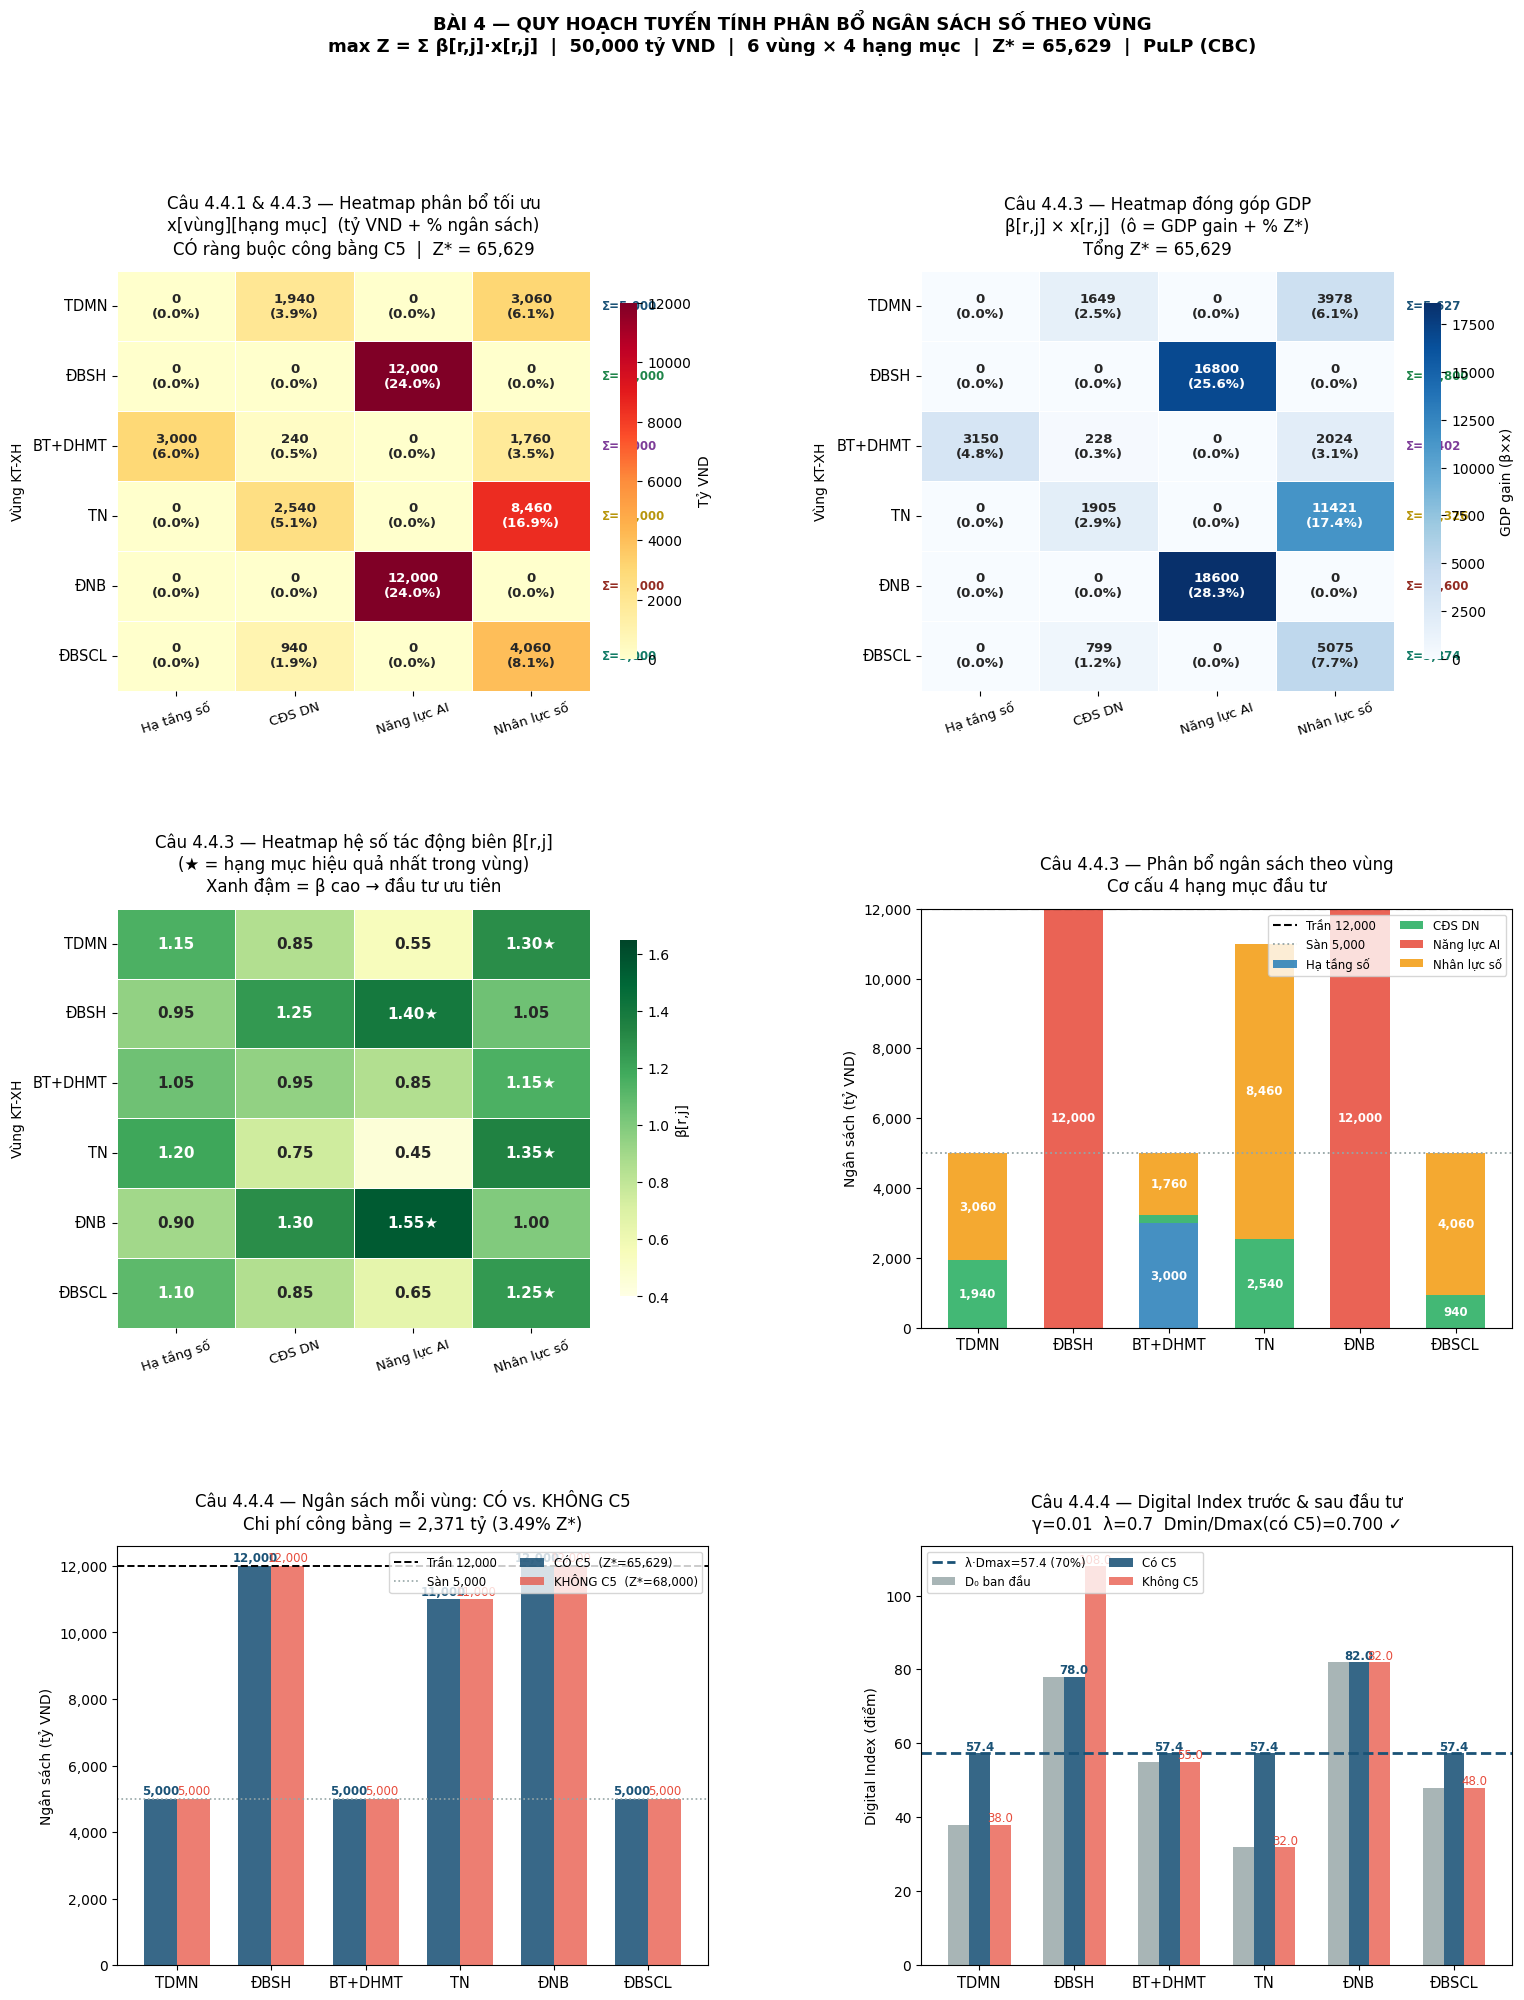

In [22]:
fig1 = plt.figure(figsize=(18, 22))
fig1.patch.set_facecolor('white')
gs1  = GridSpec(3, 2, figure=fig1, hspace=0.52, wspace=0.36)

# P1: Heatmap phân bổ x[r,j]
ax1 = fig1.add_subplot(gs1[0, 0])
df_hm1 = pd.DataFrame(X_eq, index=REGIONS,
                        columns=[f.replace(' (I)','(I)').replace(' (D)','(D)')
                                  .replace(' (AI)','(AI)').replace(' (H)','(H)')
                                  for f in ITEMS_F])
annot1 = np.array([[f'{X_eq[r,j]:,.0f}\n({X_eq[r,j]/BUDGET*100:.1f}%)'
                    for j in range(J)] for r in range(R)])
sns.heatmap(df_hm1, ax=ax1,
            annot=annot1, fmt='', cmap='YlOrRd',
            linewidths=0.7, linecolor='white',
            annot_kws={'size': 9.5, 'weight': 'bold'},
            cbar_kws={'label': 'Tỷ VND', 'shrink': 0.85})
for r in range(R):
    ax1.text(J+0.1, r+0.5, f'Σ={vung_tot[r]:,.0f}',
             va='center', ha='left', fontsize=8.5,
             color=C_VUNG[r], fontweight='bold')
ax1.set_title('Câu 4.4.1 & 4.4.3 — Heatmap phân bổ tối ưu\n'
              f'x[vùng][hạng mục]  (tỷ VND + % ngân sách)\n'
              f'CÓ ràng buộc công bằng C5  |  Z* = {Z_eq:,.0f}', pad=12)
ax1.set_ylabel('Vùng KT-XH', labelpad=6)
ax1.tick_params(axis='x', rotation=18, labelsize=9.5)
ax1.tick_params(axis='y', rotation=0,  labelsize=10.5)

# P2: Heatmap GDP gain β*x
ax2 = fig1.add_subplot(gs1[0, 1])
df_hm2 = pd.DataFrame(gdp_gain, index=REGIONS,
                        columns=[f.replace(' (I)','(I)').replace(' (D)','(D)')
                                  .replace(' (AI)','(AI)').replace(' (H)','(H)')
                                  for f in ITEMS_F])
annot2 = np.array([[f'{gdp_gain[r,j]:.0f}\n({gdp_gain[r,j]/Z_eq*100:.1f}%)'
                    for j in range(J)] for r in range(R)])
sns.heatmap(df_hm2, ax=ax2,
            annot=annot2, fmt='', cmap='Blues',
            linewidths=0.7, linecolor='white',
            annot_kws={'size': 9.5, 'weight': 'bold'},
            cbar_kws={'label': 'GDP gain (β×x)', 'shrink': 0.85})
for r in range(R):
    ax2.text(J+0.1, r+0.5, f'Σ={gdp_vung[r]:,.0f}',
             va='center', ha='left', fontsize=8.5,
             color=C_VUNG[r], fontweight='bold')
ax2.set_title('Câu 4.4.3 — Heatmap đóng góp GDP\n'
              f'β[r,j] × x[r,j]  (ô = GDP gain + % Z*)\n'
              f'Tổng Z* = {Z_eq:,.0f}', pad=12)
ax2.set_ylabel('Vùng KT-XH', labelpad=6)
ax2.tick_params(axis='x', rotation=18, labelsize=9.5)
ax2.tick_params(axis='y', rotation=0,  labelsize=10.5)

# P3: Heatmap β[r,j] — hệ số tác động biên
ax3 = fig1.add_subplot(gs1[1, 0])
df_beta = pd.DataFrame(BETA, index=REGIONS,
                         columns=[f.replace(' (I)','(I)').replace(' (D)','(D)')
                                   .replace(' (AI)','(AI)').replace(' (H)','(H)')
                                   for f in ITEMS_F])
annot_beta = np.array([
    [f'{BETA[r,j]:.2f}{"★" if j==np.argmax(BETA[r]) else ""}'
     for j in range(J)] for r in range(R)])
sns.heatmap(df_beta, ax=ax3,
            annot=annot_beta, fmt='', cmap='YlGn',
            linewidths=0.7, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'},
            cbar_kws={'label': 'β[r,j]', 'shrink': 0.85},
            vmin=0.40, vmax=1.65)
ax3.set_title('Câu 4.4.3 — Heatmap hệ số tác động biên β[r,j]\n'
              '(★ = hạng mục hiệu quả nhất trong vùng)\n'
              'Xanh đậm = β cao → đầu tư ưu tiên', pad=12)
ax3.set_ylabel('Vùng KT-XH', labelpad=6)
ax3.tick_params(axis='x', rotation=18, labelsize=9.5)
ax3.tick_params(axis='y', rotation=0,  labelsize=10.5)

# P4: Stacked bar phân bổ theo vùng
ax4 = fig1.add_subplot(gs1[1, 1])
xp4 = np.arange(R); bot4 = np.zeros(R)
for j in range(J):
    bars = ax4.bar(xp4, X_eq[:,j], bottom=bot4,
                   label=ITEMS_F[j], color=C_ITEMS[j], alpha=0.87, width=0.62)
    for xi, (v, b) in enumerate(zip(X_eq[:,j], bot4)):
        if v > 400:
            ax4.text(xi, b+v/2, f'{v:,.0f}',
                     ha='center', va='center',
                     fontsize=8.5, color='white', fontweight='bold')
    bot4 += X_eq[:,j]

ax4.axhline(MAX_R, color='black', ls='--', lw=1.5, label=f'Trần {MAX_R:,}')
ax4.axhline(MIN_R, color=C_GRAY,  ls=':',  lw=1.3, label=f'Sàn {MIN_R:,}')
ax4.set_xticks(xp4)
ax4.set_xticklabels(REGIONS, fontsize=10.5)
ax4.set_title('Câu 4.4.3 — Phân bổ ngân sách theo vùng\n'
              'Cơ cấu 4 hạng mục đầu tư', pad=12)
ax4.set_ylabel('Ngân sách (tỷ VND)')
ax4.legend(fontsize=8.5, loc='upper right', ncol=2)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'{v:,.0f}'))

# P5: CÓ C5 vs KHÔNG C5 — grouped bar
ax5 = fig1.add_subplot(gs1[2, 0])
xp5 = np.arange(R); w5 = 0.35
b5a = ax5.bar(xp5-w5/2, vung_tot, width=w5, color=C_BLUE,
              alpha=0.87, label=f'CÓ C5  (Z*={Z_eq:,.0f})')
b5b = ax5.bar(xp5+w5/2, vung_ne,  width=w5, color=C_RED,
              alpha=0.72, label=f'KHÔNG C5  (Z*={Z_ne:,.0f})')
for bar, v in zip(b5a, vung_tot):
    ax5.text(bar.get_x()+bar.get_width()/2, v+120,
             f'{v:,.0f}', ha='center', fontsize=8.5,
             color=C_BLUE, fontweight='bold')
for bar, v in zip(b5b, vung_ne):
    ax5.text(bar.get_x()+bar.get_width()/2, v+120,
             f'{v:,.0f}', ha='center', fontsize=8.5, color=C_RED)
ax5.axhline(MAX_R, color='black', ls='--', lw=1.4, label=f'Trần {MAX_R:,}')
ax5.axhline(MIN_R, color=C_GRAY,  ls=':',  lw=1.2, label=f'Sàn {MIN_R:,}')
ax5.set_xticks(xp5)
ax5.set_xticklabels(REGIONS, fontsize=10.5)
ax5.set_title(f'Câu 4.4.4 — Ngân sách mỗi vùng: CÓ vs. KHÔNG C5\n'
              f'Chi phí công bằng = {cost:,.0f} tỷ ({cpct:.2f}% Z*)', pad=12)
ax5.set_ylabel('Ngân sách (tỷ VND)')
ax5.legend(fontsize=8.5, loc='upper right', ncol=2)
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'{v:,.0f}'))

# P6: Digital Index trước & sau đầu tư
ax6 = fig1.add_subplot(gs1[2, 1])
xp6 = np.arange(R); w6 = 0.22

thresh = LAMBDA * Dmax # Define thresh here

ax6.bar(xp6-w6,  D0,    width=w6, color='#95a5a6', alpha=0.82, label='D₀ ban đầu')
ax6.bar(xp6,     D_eq,  width=w6, color=C_BLUE,    alpha=0.88, label='Có C5')
ax6.bar(xp6+w6,  D_ne,  width=w6, color=C_RED,     alpha=0.72, label='Không C5')
ax6.axhline(thresh, color=C_BLUE, ls='--', lw=2,
            label=f'λ·Dmax={thresh:.1f} (70%)')
for r in range(R):
    ax6.text(xp6[r],    D_eq[r]+0.8, f'{D_eq[r]:.1f}',
             ha='center', fontsize=8.5, color=C_BLUE, fontweight='bold')
    ax6.text(xp6[r]+w6, D_ne[r]+0.8, f'{D_ne[r]:.1f}',
             ha='center', fontsize=8.5, color=C_RED)
ax6.set_xticks(xp6)
ax6.set_xticklabels(REGIONS, fontsize=10.5)
ax6.set_title(f'Câu 4.4.4 — Digital Index trước & sau đầu tư\n'
              f'γ={GAMMA}  λ={LAMBDA}  Dmin/Dmax(có C5)={ratio:.3f} '
              f'{"✓" if ratio>=LAMBDA-1e-3 else "✗"}', pad=12)
ax6.set_ylabel('Digital Index (điểm)')
ax6.legend(fontsize=8.5, loc='upper left', ncol=2)

fig1.suptitle(
    'BÀI 4 — QUY HOẠCH TUYẾN TÍNH PHÂN BỔ NGÂN SÁCH SỐ THEO VÙNG\n'
    f'max Z = Σ β[r,j]·x[r,j]  |  {BUDGET:,} tỷ VND  |  '
    f'6 vùng × 4 hạng mục  |  Z* = {Z_eq:,.0f}  |  PuLP (CBC)',
    fontsize=13, fontweight='bold', y=0.999,
)
plt.show()